In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.tree          import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics       import (accuracy_score, precision_score,recall_score, f1_score,confusion_matrix, classification_report)


# (i)  READ DATASET INTO DATAFRAME
df = pd.read_csv('loan_approval.csv')

print(" Dataset Loaded")
print(df.head(5).to_string(index=False))
print(f"\n  Shape   : {df.shape}")
print(f"  Columns : {list(df.columns)}")
print("\n  Target Distribution:")
vc = df['loan_approval'].value_counts()
print(f"  Approved (1) : {vc[1]}  |  Rejected (0) : {vc[0]}")
print("\n  Statistical Summary:")
print(df.describe().round(2))

 Dataset Loaded
 age  income  loan_amount  credit_score  employment_yrs  debt_ratio  num_dependents  existing_loans  education  loan_approval
  59   58623       134019           557               8        0.20               0               2          2              0
  49   27392        75726           796              13        0.81               3               0          1              0
  35   75680       151564           459               0        0.57               3               2          1              0
  63  146354       387812           774              18        0.64               4               3          2              1
  28   66717       278246           679              12        0.73               0               1          3              1

  Shape   : (200, 10)
  Columns : ['age', 'income', 'loan_amount', 'credit_score', 'employment_yrs', 'debt_ratio', 'num_dependents', 'existing_loans', 'education', 'loan_approval']

  Target Distribution:
  Approved (1) : 120  

In [2]:
# (ii)  SEPARATE INPUT FEATURES and TARGET
features = ['age', 'income', 'loan_amount', 'credit_score','employment_yrs', 'debt_ratio', 'num_dependents','existing_loans', 'education']
X = df[features]
y = df['loan_approval']
print(" Features and Target Separated")
print(f"  Input Features ({len(features)}): {features}")
print(f"  Target   : loan_approval  (0=Rejected, 1=Approved)")

 Features and Target Separated
  Input Features (9): ['age', 'income', 'loan_amount', 'credit_score', 'employment_yrs', 'debt_ratio', 'num_dependents', 'existing_loans', 'education']
  Target   : loan_approval  (0=Rejected, 1=Approved)


In [3]:
# (iii)  SPLIT DATASET — 70:30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)
print("Train-Test Split  (70 : 30)")
print(f"  Training samples : {len(X_train)}  (70%)")
print(f"  Testing  samples : {len(X_test)}   (30%)")
print(f"\n  Train — Approved: {sum(y_train==1)}  |  Rejected: {sum(y_train==0)}")
print(f"  Test  — Approved: {sum(y_test==1)}   |  Rejected: {sum(y_test==0)}")

Train-Test Split  (70 : 30)
  Training samples : 140  (70%)
  Testing  samples : 60   (30%)

  Train — Approved: 82  |  Rejected: 58
  Test  — Approved: 38   |  Rejected: 22


In [4]:
# (iv)  TRAIN DECISION TREE CLASSIFIER
# max_depth=4 keeps tree readable and avoids overfitting
dt = DecisionTreeClassifier(max_depth=4, random_state=42, criterion='gini')
dt.fit(X_train, y_train)
print(" Decision Tree Trained ")
print(f"  Criterion : Gini Impurity")
print(f"  Max Depth : {dt.max_depth}")
print(f"  Tree Depth (actual) : {dt.get_depth()}")
print(f"  Number of Leaves    : {dt.get_n_leaves()}")
print("\n  Decision Tree Rules (text):")
print(export_text(dt, feature_names=features))

 Decision Tree Trained 
  Criterion : Gini Impurity
  Max Depth : 4
  Tree Depth (actual) : 4
  Number of Leaves    : 12

  Decision Tree Rules (text):
|--- income <= 87566.50
|   |--- credit_score <= 662.00
|   |   |--- employment_yrs <= 20.00
|   |   |   |--- class: 0
|   |   |--- employment_yrs >  20.00
|   |   |   |--- credit_score <= 503.50
|   |   |   |   |--- class: 0
|   |   |   |--- credit_score >  503.50
|   |   |   |   |--- class: 1
|   |--- credit_score >  662.00
|   |   |--- income <= 37209.50
|   |   |   |--- employment_yrs <= 20.00
|   |   |   |   |--- class: 0
|   |   |   |--- employment_yrs >  20.00
|   |   |   |   |--- class: 1
|   |   |--- income >  37209.50
|   |   |   |--- employment_yrs <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- employment_yrs >  0.50
|   |   |   |   |--- class: 1
|--- income >  87566.50
|   |--- credit_score <= 347.50
|   |   |--- class: 0
|   |--- credit_score >  347.50
|   |   |--- loan_amount <= 311992.00
|   |   |   |--- employmen

In [6]:
# (v)  CLASSIFY TEST DATA
y_pred      = dt.predict(X_test)
y_pred_prob = dt.predict_proba(X_test)[:, 1]
print(" Test Data Classification Results")
results_df = X_test.copy()
results_df['Actual']    = y_test.values
results_df['Predicted'] = y_pred
results_df['Correct']   = (y_test.values == y_pred)
print(results_df.head(15).to_string(index=False))

 Test Data Classification Results
 age  income  loan_amount  credit_score  employment_yrs  debt_ratio  num_dependents  existing_loans  education  Actual  Predicted  Correct
  31   86690       199407           810              15        0.40               4               1          2       1          1     True
  23  118506       455101           552              25        0.56               1               3          2       1          0    False
  62   42671       115864           756              26        0.43               2               1          3       1          1     True
  48   25895       457556           615              23        0.56               3               3          3       0          1    False
  46  114179       235913           357              13        0.20               4               0          2       1          1     True
  55  102018       384710           755               4        0.73               0               0          3       1          0   

In [7]:
# (vi)  EVALUATE PERFORMANCE
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print(" Evaluation Metrics")

print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")

print(f"""
  Confusion Matrix:
  
              Predicted             
           Rejected | Approved     
 
    Actual                      
   Rejected  TN={TN:>3}  │  FP={FP:>3}  
   Approved  FN={FN:>3}  │  TP={TP:>3}    """)

print("  Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))

# Feature Importances
print("  Feature Importances (higher = more influential):")
print(f"  {'Feature':<18} {'Importance':>12}")
print("  " + "-" * 32)
for feat, imp in sorted(zip(features, dt.feature_importances_),
                         key=lambda x: -x[1]):
    bar = '' * int(imp * 40)
    print(f"  {feat:<18} {imp:>8.4f}   {bar}")

 Evaluation Metrics
  Accuracy  : 78.33%
  Precision : 87.88%
  Recall    : 76.32%
  F1 Score  : 81.69%

  Confusion Matrix:

              Predicted             
           Rejected | Approved     

    Actual                      
   Rejected  TN= 18  │  FP=  4  
   Approved  FN=  9  │  TP= 29    
  Full Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.67      0.82      0.73        22
Approved (1)       0.88      0.76      0.82        38

    accuracy                           0.78        60
   macro avg       0.77      0.79      0.78        60
weighted avg       0.80      0.78      0.79        60

  Feature Importances (higher = more influential):
  Feature              Importance
  --------------------------------
  income               0.4647   
  credit_score         0.3966   
  employment_yrs       0.1190   
  loan_amount          0.0196   
  age                  0.0000   
  debt_ratio           0.0000   
  num_dependents       0

Text(0.5, 1.0, 'Decision Tree — Loan Approval\n(max_depth=4, criterion=Gini)')

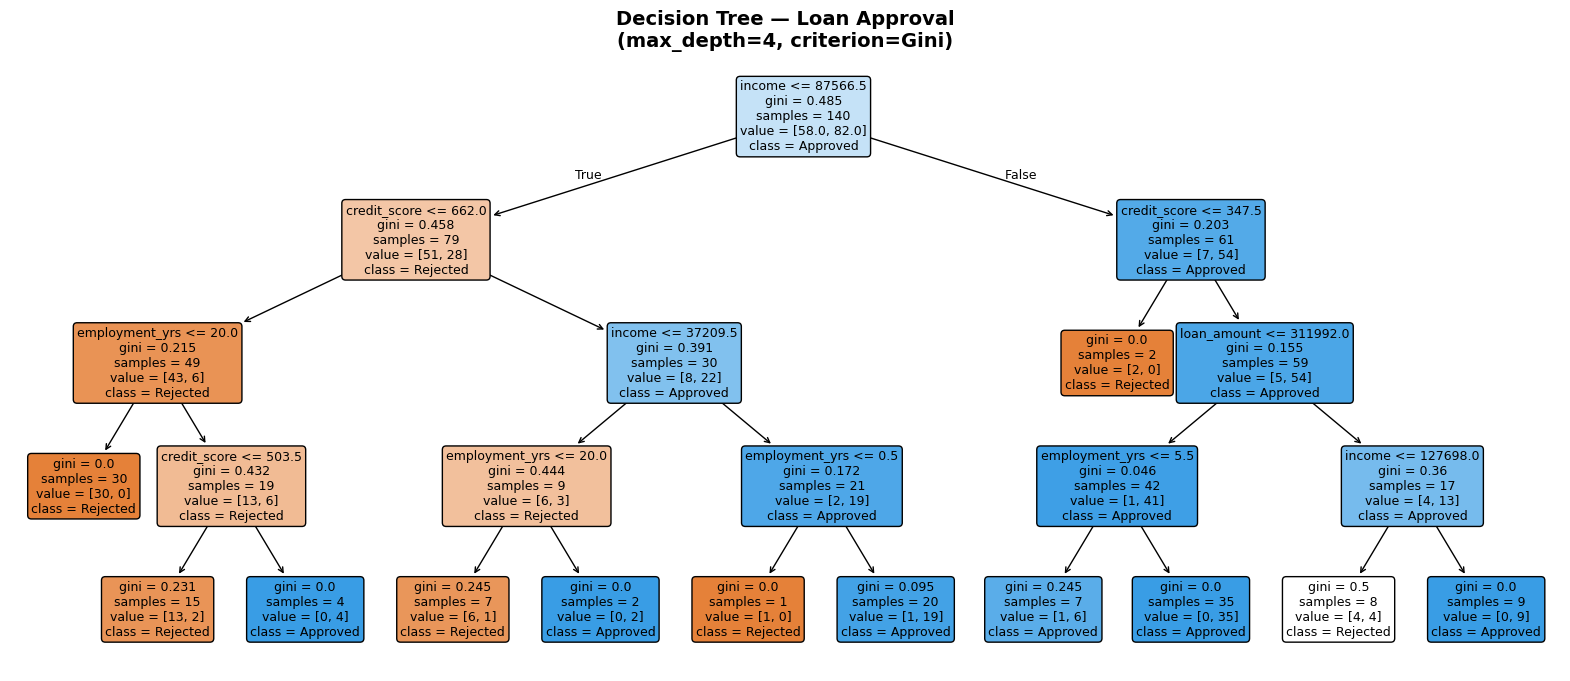

In [8]:
# PLOT 1 : Decision Tree Visualization
plt.figure(figsize=(20, 8))
plot_tree(dt,feature_names=features,class_names=['Rejected', 'Approved'],filled=True,rounded=True,fontsize=9)
plt.title('Decision Tree — Loan Approval\n(max_depth=4, criterion=Gini)',fontsize=14, fontweight='bold')

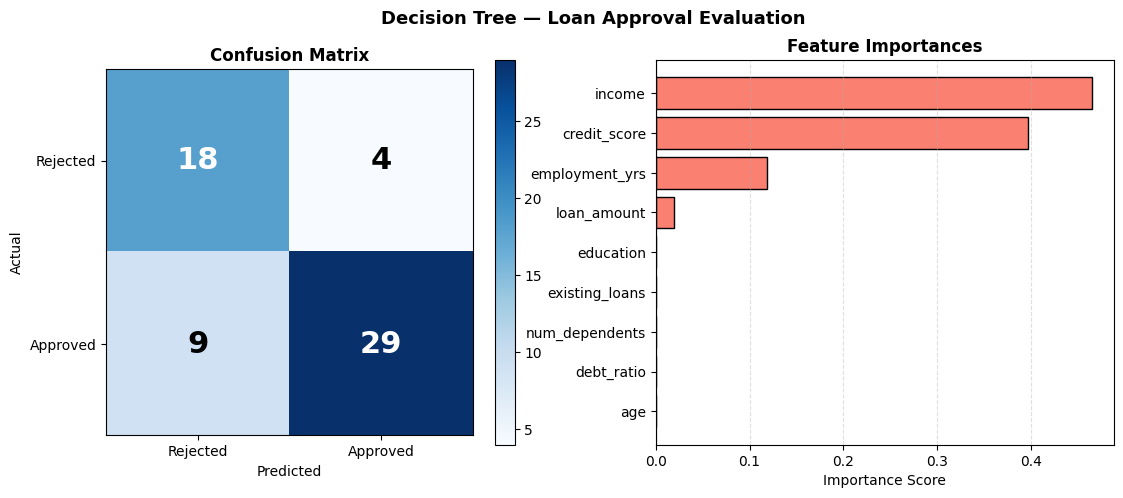

In [10]:
# PLOT 2 : Confusion Matrix Heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Decision Tree — Loan Approval Evaluation',
             fontsize=13, fontweight='bold')

im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Rejected', 'Approved'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['Rejected', 'Approved'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=22,fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[0])

# PLOT 3 : Feature Importance Bar Chart
imp_sorted = sorted(zip(features, dt.feature_importances_),
                    key=lambda x: x[1])
feats_sorted, imps_sorted = zip(*imp_sorted)

colors = ['steelblue' if i < len(feats_sorted)//2 else 'salmon'
          for i in range(len(feats_sorted))]
axes[1].barh(feats_sorted, imps_sorted, color=colors, edgecolor='black')
axes[1].set_title('Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

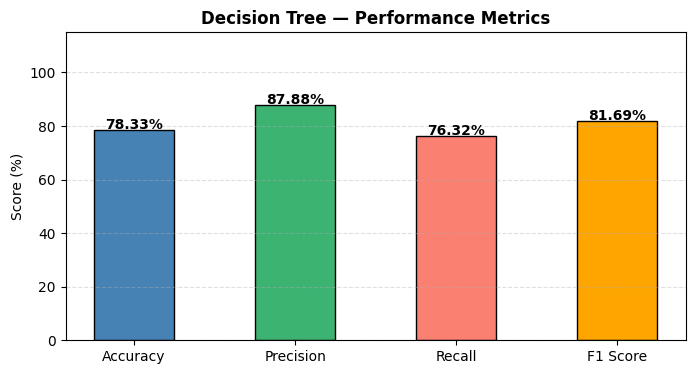

In [11]:
# PLOT 4 : Metrics Summary Bar

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [acc, prec, rec, f1]
colors2 = ['steelblue', 'mediumseagreen', 'salmon', 'orange']

plt.figure(figsize=(8, 4))
bars = plt.bar(metrics, [v*100 for v in values],color=colors2, edgecolor='black', width=0.5)
for b, v in zip(bars, values):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,f'{v*100:.2f}%', ha='center', fontweight='bold')
plt.title('Decision Tree — Performance Metrics', fontweight='bold')
plt.ylabel('Score (%)')
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.4)

In [12]:
# (vii)  PREDICT FOR NEW LOAN APPLICANT
print(" Predict Loan Approval for New Applicant\n")
print("  (education: 1=School, 2=UG, 3=PG)\n")
try:
    age_v  = float(input("  Age                    : "))
    inc_v  = float(input("  Annual Income (₹)      : "))
    loan_v = float(input("  Loan Amount (₹)        : "))
    cred_v = float(input("  Credit Score (300-850)  : "))
    emp_v  = float(input("  Employment Years       : "))
    debt_v = float(input("  Debt Ratio (0.1-0.9)   : "))
    dep_v  = float(input("  Number of Dependents   : "))
    exl_v  = float(input("  Existing Loans         : "))
    edu_v  = float(input("  Education Level (1-3)  : "))

    new_app = pd.DataFrame(
        [[age_v, inc_v, loan_v, cred_v, emp_v, debt_v, dep_v, exl_v, edu_v]],
        columns=features)
    pred     = dt.predict(new_app)[0]
    pred_prob= dt.predict_proba(new_app)[0]

    print(f"\n   Decision  : {' APPROVED (1)' if pred == 1 else ' REJECTED (0)'}")
    print(f"  Probability — Rejected : {pred_prob[0]*100:.2f}%")
    print(f"  Probability — Approved : {pred_prob[1]*100:.2f}%")

except Exception:
    samples = [
        [35, 120000, 50000, 780, 10, 0.2, 1, 0, 3],  # strong → Approved
        [22,  18000, 400000, 320,  0, 0.8, 3, 3, 1],  # weak   → Rejected
    ]
    labels = ["Strong applicant", "Weak applicant"]
    print("  (Non-interactive — sample predictions)\n")
    for s, lbl in zip(samples, labels):
        new_app  = pd.DataFrame([s], columns=features)
        pred     = dt.predict(new_app)[0]
        prob     = dt.predict_proba(new_app)[0]
        print(f"  {lbl}: {dict(zip(features, s))}")
        print(f"  → Decision: {' APPROVED' if pred==1 else ' REJECTED'}"
              f"  |  Rejected: {prob[0]*100:.1f}%  Approved: {prob[1]*100:.1f}%\n")

 Predict Loan Approval for New Applicant

  (education: 1=School, 2=UG, 3=PG)



  Age                    :  40
  Annual Income (₹)      :  524000
  Loan Amount (₹)        :  2070486
  Credit Score (300-850)  :  860
  Employment Years       :  14
  Debt Ratio (0.1-0.9)   :  0.57
  Number of Dependents   :  6
  Existing Loans         :  1
  Education Level (1-3)  :  2



   Decision  :  APPROVED (1)
  Probability — Rejected : 0.00%
  Probability — Approved : 100.00%
